In [42]:
import struct
import numpy as np
import csv
import os
from scipy.integrate import simpson as simps
import matplotlib.pyplot as plt
from tqdm import trange



In [43]:
def csv_reader(file_name,save=False):
    data_csv = np.genfromtxt(file_name, delimiter=",", skip_header=3)
    length = len(data_csv[:, 0])
    size = length//1000
    print(size)
    time_csv = data_csv[:, 0]   # time column
    ch1_csv = data_csv[:, 1]    # channel 1
    ch2_csv = data_csv[:, 2]    # channel 2
    # ch3_csv = data_csv[:, 3]    # channel 3
    common_dtype = [
    ('event_number', np.int32),
    ('start_time', np.float64),
    ('baseline', np.float32),
    ('baseline_std', np.float32),
    ('1_peak_location', int),
    ('1_peak_value', np.float32),
    ('2_peak_location', int),
    ('2_peak_value', np.float32),
    ('1_peak_area', np.float32),
    ('2_peak_area', np.float32),]
    if save:
        common_dtype.append(('data', np.float32, 1000))
        nd_array = np.full(size, np.nan, dtype=common_dtype)
        channels_data ={1:nd_array.copy(),2:nd_array.copy(),3:nd_array.copy()}
        for i in trange (size,desc="Processing events"):
            time_i=time_csv[i*1000:(i+1)*1000]  ##2.5 ns time resolution    
            ch1_i=ch1_csv[i*1000:(i+1)*1000]*(-1)   
            ch2_i=ch2_csv[i*1000:(i+1)*1000]*(-1)    
            # ch3_i=ch3_csv[i*1000:(i+1)*1000]*(-1) 
            channels_data[1]['data'][i] = ch1_i
            channels_data[2]['data'][i] = ch2_i
            # channels_data[3]['data'][i] = ch3_i
            channels_data[1]['event_number'][i] = i
            channels_data[2]['event_number'][i] = i
            # channels_data[3]['event_number'][i] = i
            channels_data[1]['start_time'][i] = time_i[0]
            channels_data[2]['start_time'][i] = time_i[0]
            # channels_data[3]['start_time'][i] = time_i[0]
            channels_data[1]['baseline'][i] = np.average(ch1_i[0:30])
            channels_data[2]['baseline'][i] = np.average(ch2_i[0:30])
            # channels_data[3]['baseline'][i] = np.average(ch3_i[0:30])
            channels_data[1]['baseline_std'][i] = np.std(ch1_i[0:30])
            channels_data[2]['baseline_std'][i] = np.std(ch2_i[0:30])
            # channels_data[3]['baseline_std'][i] = np.std(ch3_i[0:30])
            channels_data[1]['1_peak_value'][i] = np.max(ch1_i)
            channels_data[2]['1_peak_value'][i] = np.max(ch2_i)
            # channels_data[3]['1_peak_value'][i] = np.max(ch3_i)
            channels_data[1]['1_peak_location'][i] = int(np.argmax(ch1_i))
            channels_data[2]['1_peak_location'][i] = int(np.argmax(ch2_i))
            # channels_data[3]['1_peak_location'][i] = int(np.argmax(ch3_i))
            ## 33 samples is 338(2.5*(2000/781)) ns sepeartion from peak side, have to be to the right for muon decay
            
            ind_ch1_peak_1_l = int(np.argmax(ch1_i))-33
            ind_ch2_peak_1_l = int(np.argmax(ch2_i))-33
            # ind_ch3_peak_1_l = int(np.argmax(ch3_i))-33
            if ind_ch1_peak_1_l < 0:
                ind_ch1_peak_1_l = 0
            if ind_ch2_peak_1_l < 0:
                ind_ch2_peak_1_l = 0
            # if ind_ch3_peak_1_l < 0:
            #     ind_ch3_peak_1_l = 0
            ind_ch1_peak_1_r = int(np.argmax(ch1_i))+33
            ind_ch2_peak_1_r = int(np.argmax(ch2_i))+33
            # ind_ch3_peak_1_r = int(np.argmax(ch3_i))+33
            if ind_ch1_peak_1_r > 999:
                ind_ch1_peak_1_r = 999
            if ind_ch2_peak_1_r > 999:
                ind_ch2_peak_1_r = 999
            # if ind_ch3_peak_1_r > 999:
            #     ind_ch3_peak_1_r = 999
            
            channels_data[1]['2_peak_value'][i] = np.max(ch1_i[ind_ch1_peak_1_r:])
            channels_data[2]['2_peak_value'][i] = np.max(ch2_i[ind_ch2_peak_1_r:])
            # channels_data[3]['2_peak_value'][i] = np.max(ch3_i[ind_ch3_peak_1_r:])
            channels_data[1]['2_peak_location'][i] = int(
                np.argmax(ch1_i[ind_ch1_peak_1_r:])+ind_ch1_peak_1_r)
            channels_data[2]['2_peak_location'][i] = int(
                np.argmax(ch2_i[ind_ch2_peak_1_r:])+ind_ch2_peak_1_r)
            # channels_data[3]['2_peak_location'][i] = int(
            #     np.argmax(ch3_i[ind_ch3_peak_1_r:])+ind_ch3_peak_1_r)
            channels_data[1]['1_peak_area'][i] =  simps(ch1_i[ind_ch1_peak_1_l:ind_ch1_peak_1_r],
                                                              time_i[ind_ch1_peak_1_l:ind_ch1_peak_1_r])
            channels_data[2]['1_peak_area'][i] =  simps(ch2_i[ind_ch2_peak_1_l:ind_ch2_peak_1_r],
                                                              time_i[ind_ch2_peak_1_l:ind_ch2_peak_1_r])
            # channels_data[3]['1_peak_area'][i] =  simps(ch3_i[ind_ch3_peak_1_l:ind_ch3_peak_1_r],
            #                                                   time_i[ind_ch3_peak_1_l:ind_ch3_peak_1_r]) 
            ind_ch1_peak_2_l = channels_data[1]['2_peak_location'][i]-33
            ind_ch2_peak_2_l = channels_data[2]['2_peak_location'][i]-33
            # ind_ch3_peak_2_l = channels_data[3]['2_peak_location'][i]-33
            if ind_ch1_peak_2_l < 0:
                ind_ch1_peak_2_l = 0
            if ind_ch2_peak_2_l < 0:
                ind_ch2_peak_2_l = 0
            # if ind_ch3_peak_2_l < 0:
            #     ind_ch3_peak_2_l = 0
            ind_ch1_peak_2_r = channels_data[1]['2_peak_location'][i]+33
            ind_ch2_peak_2_r = channels_data[2]['2_peak_location'][i]+33
            # ind_ch3_peak_2_r = channels_data[3]['2_peak_location'][i]+33
            if ind_ch1_peak_2_r > 999:
                ind_ch1_peak_2_r = 999
            if ind_ch2_peak_2_r > 999:
                ind_ch2_peak_2_r = 999
            # if ind_ch3_peak_2_r > 999:
            #     ind_ch3_peak_2_r = 999           
            channels_data[1]['2_peak_area'][i] =  simps(
                ch1_i[ind_ch1_peak_2_l:ind_ch1_peak_2_r],
                    time_i[ind_ch1_peak_2_l:ind_ch1_peak_2_r])
            channels_data[2]['2_peak_area'][i] =  simps(
                ch2_i[ind_ch2_peak_2_l:ind_ch2_peak_2_r],
                    time_i[ind_ch2_peak_2_l:ind_ch2_peak_2_r])
            # channels_data[3]['2_peak_area'][i] =  simps(
            #     ch3_i[ind_ch3_peak_2_l:ind_ch3_peak_2_r],
            #         time_i[ind_ch3_peak_2_l:ind_ch3_peak_2_r])

            
        return(channels_data)

    else:    
        nd_array = np.full(size, np.nan, dtype=common_dtype)
        channels_data ={1:nd_array.copy(),2:nd_array.copy(),3:nd_array.copy()}
        for i in trange (size,desc="Processing events"):
            time_i=time_csv[i*1000:(i+1)*1000] ##2.5*(2000/781) ns time resolution    
            ch1_i=ch1_csv[i*1000:(i+1)*1000]*(-1)     
            ch2_i=ch2_csv[i*1000:(i+1)*1000]*(-1)     
            # ch3_i=ch3_csv[i*1000:(i+1)*1000]*(-1) 
            channels_data[1]['event_number'][i] = i
            channels_data[2]['event_number'][i] = i
            # channels_data[3]['event_number'][i] = i
            channels_data[1]['start_time'][i] = time_i[0]
            channels_data[2]['start_time'][i] = time_i[0]
            # channels_data[3]['start_time'][i] = time_i[0]
            channels_data[1]['baseline'][i] = np.average(ch1_i[0:30])
            channels_data[2]['baseline'][i] = np.average(ch2_i[0:30])
            # channels_data[3]['baseline'][i] = np.average(ch3_i[0:30])
            channels_data[1]['baseline_std'][i] = np.std(ch1_i[0:30])
            channels_data[2]['baseline_std'][i] = np.std(ch2_i[0:30])
            # channels_data[3]['baseline_std'][i] = np.std(ch3_i[0:30])
            channels_data[1]['1_peak_value'][i] = np.max(ch1_i)
            channels_data[2]['1_peak_value'][i] = np.max(ch2_i)
            # channels_data[3]['1_peak_value'][i] = np.max(ch3_i)
            channels_data[1]['1_peak_location'][i] = int(np.argmax(ch1_i))
            channels_data[2]['1_peak_location'][i] = int(np.argmax(ch2_i))
            # channels_data[3]['1_peak_location'][i] = int(np.argmax(ch3_i))
            ## 33 samples is 338(2.5*(2000/781)) ns sepeartion from peak side, have to be to the right for muon decay
            
            ind_ch1_peak_1_l = int(np.argmax(ch1_i))-33
            ind_ch2_peak_1_l = int(np.argmax(ch2_i))-33
            # ind_ch3_peak_1_l = int(np.argmax(ch3_i))-33
            if ind_ch1_peak_1_l < 0:
                ind_ch1_peak_1_l = 0
            if ind_ch2_peak_1_l < 0:
                ind_ch2_peak_1_l = 0
            # if ind_ch3_peak_1_l < 0:
            #     ind_ch3_peak_1_l = 0
            ind_ch1_peak_1_r = int(np.argmax(ch1_i))+33
            ind_ch2_peak_1_r = int(np.argmax(ch2_i))+33
            # ind_ch3_peak_1_r = int(np.argmax(ch3_i))+33
            if ind_ch1_peak_1_r > 999:
                ind_ch1_peak_1_r = 999
            if ind_ch2_peak_1_r > 999:
                ind_ch2_peak_1_r = 999
            # if ind_ch3_peak_1_r > 999:
            #     ind_ch3_peak_1_r = 999
            
            channels_data[1]['2_peak_value'][i] = np.max(ch1_i[ind_ch1_peak_1_r:])
            channels_data[2]['2_peak_value'][i] = np.max(ch2_i[ind_ch2_peak_1_r:])
            # channels_data[3]['2_peak_value'][i] = np.max(ch3_i[ind_ch3_peak_1_r:])
            channels_data[1]['2_peak_location'][i] = int(
                np.argmax(ch1_i[ind_ch1_peak_1_r:])+ind_ch1_peak_1_r)
            channels_data[2]['2_peak_location'][i] = int(
                np.argmax(ch2_i[ind_ch2_peak_1_r:])+ind_ch2_peak_1_r)
            # channels_data[3]['2_peak_location'][i] = int(
            #     np.argmax(ch3_i[ind_ch3_peak_1_r:])+ind_ch3_peak_1_r)
            channels_data[1]['1_peak_area'][i] =  simps(ch1_i[ind_ch1_peak_1_l:ind_ch1_peak_1_r],
                                                              time_i[ind_ch1_peak_1_l:ind_ch1_peak_1_r])
            channels_data[2]['1_peak_area'][i] =  simps(ch2_i[ind_ch2_peak_1_l:ind_ch2_peak_1_r],
                                                              time_i[ind_ch2_peak_1_l:ind_ch2_peak_1_r])
            # channels_data[3]['1_peak_area'][i] =  simps(ch3_i[ind_ch3_peak_1_l:ind_ch3_peak_1_r],
            #                                                   time_i[ind_ch3_peak_1_l:ind_ch3_peak_1_r]) 
            ind_ch1_peak_2_l = channels_data[1]['2_peak_location'][i]-33
            ind_ch2_peak_2_l = channels_data[2]['2_peak_location'][i]-33
            # ind_ch3_peak_2_l = channels_data[3]['2_peak_location'][i]-33
            if ind_ch1_peak_2_l < 0:
                ind_ch1_peak_2_l = 0
            if ind_ch2_peak_2_l < 0:
                ind_ch2_peak_2_l = 0
            # if ind_ch3_peak_2_l < 0:
            #     ind_ch3_peak_2_l = 0
            ind_ch1_peak_2_r = channels_data[1]['2_peak_location'][i]+33
            ind_ch2_peak_2_r = channels_data[2]['2_peak_location'][i]+33
            # ind_ch3_peak_2_r = channels_data[3]['2_peak_location'][i]+33
            if ind_ch1_peak_2_r > 999:
                ind_ch1_peak_2_r = 999
            if ind_ch2_peak_2_r > 999:
                ind_ch2_peak_2_r = 999
            # if ind_ch3_peak_2_r > 999:
            #     ind_ch3_peak_2_r = 780           
            channels_data[1]['2_peak_area'][i] =  simps(
                ch1_i[ind_ch1_peak_2_l:ind_ch1_peak_2_r],
                    time_i[ind_ch1_peak_2_l:ind_ch1_peak_2_r])
            channels_data[2]['2_peak_area'][i] =  simps(
                ch2_i[ind_ch2_peak_2_l:ind_ch2_peak_2_r],
                    time_i[ind_ch2_peak_2_l:ind_ch2_peak_2_r])
            # channels_data[3]['2_peak_area'][i] =  simps(
            #     ch3_i[ind_ch3_peak_2_l:ind_ch3_peak_2_r],
            #         time_i[ind_ch3_peak_2_l:ind_ch3_peak_2_r])

        return(channels_data)
    
    


In [44]:
procceseced_data=csv_reader("/Users/drorta/alpha-1/measurements/nd-2-measurement-0.csv",save=True)

640


Processing events: 100%|██████████| 640/640 [00:00<00:00, 3275.58it/s]


In [45]:
ch_1,ch_2,ch_3=procceseced_data[1],procceseced_data[2],procceseced_data[3]

In [46]:
for i in range (0,1):
    if i == 1:
        procceseced_data=csv_reader(f"/Users/drorta/alpha-1/measurements/nd-2-measurement-{i}.csv",save=True)
        ch_1,ch_2,ch_3=procceseced_data[1],procceseced_data[2],procceseced_data[3]
    else:
        procceseced_data=csv_reader(f"/Users/drorta/alpha-1/measurements/nd-2-measurement-{i}.csv",save=True)
        ch_1_t,ch_2_t,ch_3_t=procceseced_data[1],procceseced_data[2],procceseced_data[3]
        ch_1_t['event_number'] = ch_1_t['event_number']+ch_1['event_number'][-1]
        ch_1_t['start_time'] = ch_1_t['start_time']+ch_1['start_time'][-1]
        ch_2_t['event_number'] = ch_2_t['event_number']+ch_2['event_number'][-1]
        ch_3_t['start_time'] = ch_3_t['start_time']+ch_3['start_time'][-1]
        ch_3_t['event_number'] = ch_3_t['event_number']+ch_3['event_number'][-1]
        ch_3_t['start_time'] = ch_3_t['start_time']+ch_3['start_time'][-1]
        ch_1 = np.append(ch_1,ch_1_t)
        ch_2 = np.append(ch_2,ch_2_t)
        ch_3 = np.append(ch_3,ch_3_t)
        del ch_1_t , ch_2_t , ch_3_t

640


Processing events: 100%|██████████| 640/640 [00:00<00:00, 3401.22it/s]


In [47]:
def mask_channels(ch1,ch2,ch3):
    mask1 = np.abs(ch1['1_peak_location']-ch2['1_peak_location']) < 5 # first peak first board close in firts at second detector
#     mask2_1 = np.abs(ch3['baseline']/ch3['1_peak_value']) <0.1 # first peak not in third detector
    mask2 = ch3['1_peak_value'] < 0.005 # first peak not in third detector
#     mask2 = mask2_1 & mask2_2 ## on of the conditions is sufficent
#     mask3_1 = ch1['2_peak_area']/ch1['1_peak_area'] > 0.1
#     mask3_2 = ch1['2_peak_value']/ch1['1_peak_value'] > 0.15
#     mask3 =(ch1['2_peak_area']/ch1['1_peak_area'] < 1) & (~(mask3_1 & mask3_2)) ## the opposite of validatinng real 2 peaks at detector 2.
#     mask3 = (ch1['2_peak_value'] < 0.005)
    mask4 =  ch1['1_peak_value'] > 0.005
    mask5 = np.abs(ch1['2_peak_location']-ch2['2_peak_location']) > 5
    return(mask1 & mask2  & mask4& mask5)

In [48]:
mask_channels(ch_1,ch_2,ch_3)

array([False, False, False, ..., False, False, False], shape=(1280,))

In [49]:
def mask_mid_board(ch2):
#     mask1 = ch2['2_peak_area']/ch2['1_peak_area'] > 0.02
#     mask2 = ch2['2_peak_value']/ch2['1_peak_value'] > 0.1
    mask1 = ch2['1_peak_value']> 0.015
    mask2 = ch2['2_peak_value']> 0.008
    
    mask3 = ch2['2_peak_area']/ch2['1_peak_area'] < 1 ## seems not possible electron depositng more energy then muon
    return(mask1 & mask2 & mask3)
    

In [50]:
mask_mid_board(ch_2)

/var/folders/mc/9ppb87ys20gb0n6msvgthygr0000gn/T/ipykernel_57956/4069236152.py:7: RuntimeWarning: divide by zero encountered in divide
  mask3 = ch2['2_peak_area']/ch2['1_peak_area'] < 1 ## seems not possible electron depositng more energy then muon
/var/folders/mc/9ppb87ys20gb0n6msvgthygr0000gn/T/ipykernel_57956/4069236152.py:7: RuntimeWarning: invalid value encountered in divide
  mask3 = ch2['2_peak_area']/ch2['1_peak_area'] < 1 ## seems not possible electron depositng more energy then muon


array([False, False, False, ..., False, False, False], shape=(1280,))

In [51]:
ch_1_filtered=ch_1[mask_channels(ch_1,ch_2,ch_3)&mask_mid_board(ch_2)]
ch_2_filtered = ch_2[mask_channels(ch_1,ch_2,ch_3)&mask_mid_board(ch_2)]
ch_3_filtered = ch_3[mask_channels(ch_1,ch_2,ch_3)&mask_mid_board(ch_2)]

/var/folders/mc/9ppb87ys20gb0n6msvgthygr0000gn/T/ipykernel_57956/4069236152.py:7: RuntimeWarning: divide by zero encountered in divide
  mask3 = ch2['2_peak_area']/ch2['1_peak_area'] < 1 ## seems not possible electron depositng more energy then muon
/var/folders/mc/9ppb87ys20gb0n6msvgthygr0000gn/T/ipykernel_57956/4069236152.py:7: RuntimeWarning: invalid value encountered in divide
  mask3 = ch2['2_peak_area']/ch2['1_peak_area'] < 1 ## seems not possible electron depositng more energy then muon


In [52]:
len(ch_2_filtered)

0

In [53]:
for i in range(len(ch_2_filtered)):
    plt.subplot(3,1,1)
    plt.plot(ch_1_filtered['data'][i])
    plt.axvline(ch_1_filtered['2_peak_location'][i],c='r',linestyle='--')
    plt.subplot(3,1,2)
    plt.plot(ch_2_filtered['data'][i])
    plt.axvline(ch_2_filtered['2_peak_location'][i],c='r',linestyle='--')
    plt.subplot(3,1,3)
    plt.plot(ch_3_filtered['data'][i])
    plt.axvline(ch_3_filtered['2_peak_location'][i],c='r',linestyle='--')

        
    plt.show()

In [54]:
def peaks_time_diff(ch2): ## in seconds unit with 500 ns osilloscope square, 2.5ns resolution
    time_diff = ch2['2_peak_location']-ch2['1_peak_location']
    return(time_diff*2.5e-9*(2000/781))

from scipy.optimize import curve_fit


In [55]:
peaks_time_diff(ch_2_filtered) 

array([], dtype=float64)

In [56]:
def expo(t, A, tau_fit):
    return A * np.exp(-t / tau_fit)

In [57]:
# Example: replace this with your actual data array
data = peaks_time_diff(ch_2_filtered)  # your list of decay times (in ns, for example)

# Number of data points
N = len(data)

if N == 0:
    print("ERROR: No data points after filtering — check your masks and input data.")
else:
    # Use fixed IQR = 3
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1

    # Freedman–Diaconis bin width
    h = 2 * IQR / (N ** (1/3))

    # Compute data range
    data_range = data.max() - data.min()

    # Number of bins
    k = int(np.ceil(data_range / h))

    print(f"Number of bins (k) using Freedman–Diaconis with IQR: {k}")


ERROR: No data points after filtering — check your masks and input data.


In [58]:

# Number of data points
data = peaks_time_diff(ch_2_filtered)  # your list of decay times (in ns, for example)
N = len(data)

# Rice Rule: k = 2 * N^(1/3)
k = int(np.ceil(2 * N ** (1/3)))

print(f"Number of bins (k) using Rice Rule: {k}")

Number of bins (k) using Rice Rule: 0


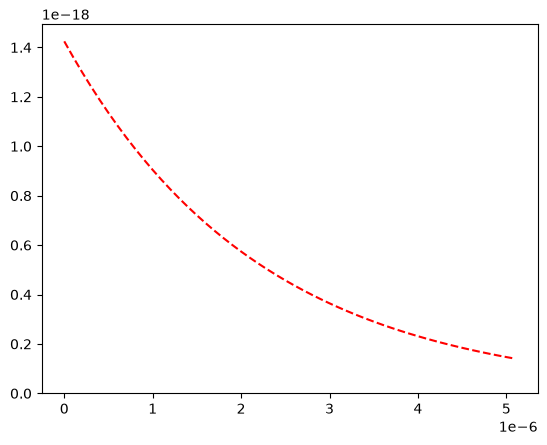

In [59]:
a,b,c=plt.hist(peaks_time_diff(ch_2_filtered) ,bins=np.arange(0.15e-6,5.05e-6,1e-6))
popt, pcov = curve_fit(expo, (b[:-1]+b[1:])/2, a, p0=(len(a), 2.2e-6))
plt.plot(np.arange(0,5.1e-6,0.1e-6), expo(np.arange(0,5.1e-6,0.1e-6), *popt), 'r--', label=f'Fit: τ = {popt[1]:.2f} μs')

In [60]:
popt,pcov**0.5

/var/folders/mc/9ppb87ys20gb0n6msvgthygr0000gn/T/ipykernel_57956/265238935.py:1: RuntimeWarning: invalid value encountered in sqrt
  popt,pcov**0.5


(array([1.42466475e-18, 2.20000000e-06]),
 array([[1.79060356e-18,            nan],
        [           nan, 5.54438196e-15]]))

# Toy MC

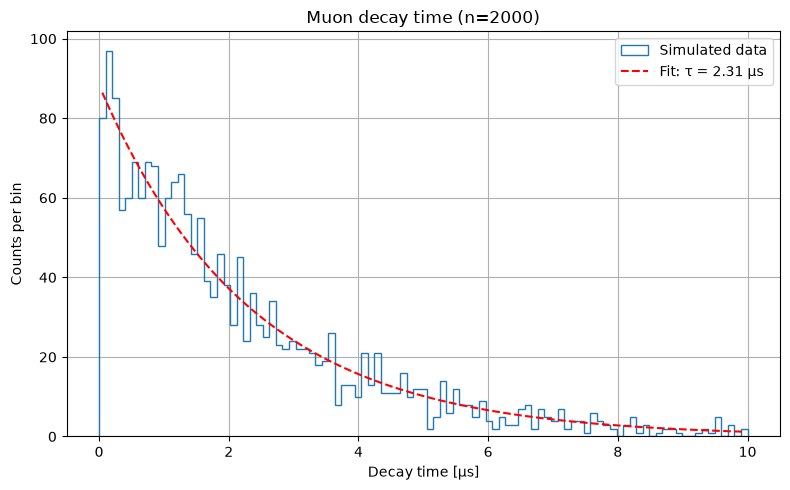

Fitted decay constant τ = 2.3137 ± 0.0834 μs


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Parameters ---
tau_mu = 2.2  # muon mean lifetime in microseconds
n_events = 2000  # Number of muon decays to simulate (adjustable)

# --- Step 1: Simulate decay times ---
decay_times = np.random.exponential(scale=tau_mu, size=n_events)

# --- Step 2: Histogram the results ---
bins = np.linspace(0, 10, 100)
hist_vals, bin_edges = np.histogram(decay_times, bins=bins)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# --- Step 3: Fit to exponential ---
def expo(t, A, tau_fit):
    return A * np.exp(-t / tau_fit)

# Use only bins with non-zero entries for fitting
mask = hist_vals > 0
popt, pcov = curve_fit(expo, bin_centers[mask], hist_vals[mask], p0=(n_events, tau_mu))

# --- Step 4: Plot ---
plt.figure(figsize=(8, 5))
plt.hist(decay_times, bins=bins, histtype='step', label='Simulated data')
plt.plot(bin_centers, expo(bin_centers, *popt), 'r--', label=f'Fit: τ = {popt[1]:.2f} μs')
plt.xlabel('Decay time [μs]')
plt.ylabel('Counts per bin')
plt.title(f'Muon decay time (n={n_events})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Step 5: Print result ---
print(f"Fitted decay constant τ = {popt[1]:.4f} ± {np.sqrt(pcov[1,1]):.4f} μs")
